In [1]:
import os
import copy
import pathlib
import json

In [2]:
from typing import Any, Mapping

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import tensorflow as tf

In [4]:
PATH = os.path.join(pathlib.Path.home(), "fs/drmdp/control/drl-experiments/1777742823/**/**/**/")

In [5]:
def load_config_data(path: str):
    files = tf.io.gfile.glob(path)
    specs = {}
    for config_file in files:
        with tf.io.gfile.GFile(config_file, "r") as readable:
            spec = json.load(readable)
            specs[spec["output_dir"]] = spec
    return specs

In [6]:
config_specs = load_config_data(os.path.join(PATH, "*-params.json"))

In [7]:
next(iter((config_specs.items())))

('/Users/guilherme/fs/drmdp/control/drl-experiments/1777742823/MountainCarContinuous-v0/exp-003/run-001',
 {'env': 'MountainCarContinuous-v0',
  'delay': 3,
  'reward_model_type': 'ircr',
  'update_every_n_steps': 50,
  'clear_buffer_on_update': False,
  'reward_model_kwargs': {},
  'num_steps': 10000,
  'sac_learning_rate': 0.0003,
  'sac_buffer_size': 100000,
  'sac_batch_size': 256,
  'sac_gradient_steps': -1,
  'log_episode_frequency': 1,
  'output_dir': '/Users/guilherme/fs/drmdp/control/drl-experiments/1777742823/MountainCarContinuous-v0/exp-003/run-001',
  'exp_name': 'exp-003',
  'run_id': 1,
  'eval_step_freq': 500,
  'n_eval_episodes': 5,
  'seed': 11,
  'agent_type': 'hc',
  'agent_kwargs': {'history_hidden_size': 128, 'reg_lambda': 5.0},
  'env_kwargs': {'max_episode_steps': 2500}})

In [8]:
def proc_spec(spec: Mapping[str, Any]) -> Mapping[str, Any]:
    new_spec = copy.copy(spec)
    # Expand spec
    new_spec["algorithm"] = new_spec["reward_model_type"] \
        if new_spec["agent_type"] == "sac" else new_spec["agent_type"]
    return new_spec

In [9]:
def load_logs_data(path: str, specs: Mapping[str, Any]):
    results_files = tf.io.gfile.glob(path)
    dfs = []
    config_keys = tuple(specs.keys())
    for result_file in results_files:
        df_rs = pd.read_json(result_file, lines=True)
        dirname = os.path.dirname(result_file)
        # Paths can be from remote cloud strorage
        # so we match on the suffix
        suffix = dirname[dirname.find("drmdp/control"):]
        spec_key = next(iter([key for key in config_keys if suffix in key]))
        spec = specs[spec_key]
        # Add spec to every row
        for key, value in proc_spec(spec).items():
            df_rs[key] = df_rs["info"].apply(lambda _: value)
        dfs.append(df_rs)
    return pd.concat(dfs, ignore_index=True)

In [10]:
df_train_logs = load_logs_data(os.path.join(PATH, "experiment-logs.jsonl"), specs=config_specs)

In [11]:
df_train_logs

,episode,steps,global_steps,returns,info,env,delay,reward_model_type,update_every_n_steps,clear_buffer_on_update,...,output_dir,exp_name,run_id,eval_step_freq,n_eval_episodes,seed,agent_type,agent_kwargs,env_kwargs,algorithm
0,1,200,200,-1233.321237,"{'total_steps': 200, 'delayed_returns': -357.4...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
1,2,200,400,-1527.222308,"{'total_steps': 400, 'delayed_returns': -173.5...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
2,3,200,600,-1172.424530,"{'total_steps': 600, 'delayed_returns': -620.5...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
3,4,200,800,-1463.687204,"{'total_steps': 800, 'delayed_returns': -55.28...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
4,1,200,200,-1480.153761,"{'sac_total_steps': 200, 'reward_model_total_s...",Pendulum-v1,3,grd,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-006,1,50,5,29,sac,{},{'max_episode_steps': 200},grd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,4,200,800,-1336.900244,"{'sac_total_steps': 800, 'reward_model_total_s...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-004,0,50,5,10,sac,{},{'max_episode_steps': 200},ircr
92,1,200,200,-877.393436,"{'sac_total_steps': 200, 'reward_model_total_s...",Pendulum-v1,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-005,0,50,5,15,sac,{},{'max_episode_steps': 200},dgra
93,2,200,400,-1007.924599,"{'sac_total_steps': 400, 'reward_model_total_s...",Pendulum-v1,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-005,0,50,5,15,sac,{},{'max_episode_steps': 200},dgra
94,3,200,600,-1345.504173,"{'sac_total_steps': 600, 'reward_model_total_s...",Pendulum-v1,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-005,0,50,5,15,sac,{},{'max_episode_steps': 200},dgra


In [12]:
df_train_logs[(df_train_logs["env"] == "MountainCarContinuous-v0") & (df_train_logs["seed"] == 1)]

,episode,steps,global_steps,returns,info,env,delay,reward_model_type,update_every_n_steps,clear_buffer_on_update,...,output_dir,exp_name,run_id,eval_step_freq,n_eval_episodes,seed,agent_type,agent_kwargs,env_kwargs,algorithm
60,1,2500,2500,-86.330287,"{'sac_total_steps': 2500, 'reward_model_total_...",MountainCarContinuous-v0,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-001,0,500,5,1,sac,{},{'max_episode_steps': 2500},dgra
61,2,2500,5000,-37.393706,"{'sac_total_steps': 5000, 'reward_model_total_...",MountainCarContinuous-v0,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-001,0,500,5,1,sac,{},{'max_episode_steps': 2500},dgra
62,3,2500,7500,-20.450452,"{'sac_total_steps': 7500, 'reward_model_total_...",MountainCarContinuous-v0,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-001,0,500,5,1,sac,{},{'max_episode_steps': 2500},dgra
63,4,2500,10000,-11.799317,"{'sac_total_steps': 10000, 'reward_model_total...",MountainCarContinuous-v0,3,dgra,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-001,0,500,5,1,sac,{},{'max_episode_steps': 2500},dgra


In [13]:
def plot_returns(df: pd.DataFrame, title: str) -> None:
    envs = sorted(df["env"].unique())
    fig, axes = plt.subplots(1, len(envs), figsize=(7 * len(envs), 5), squeeze=False)

    for ax, env in zip(axes[0], envs):
        df_env = df[df["env"] == env]
        for algo in sorted(df_env["algorithm"].unique()):
            grouped = (
                df_env[df_env["algorithm"] == algo]
                .groupby("global_steps")["returns"]
                .agg(["mean", "std"])
                .reset_index()
            )
            grouped["std"] = grouped["std"].fillna(0)

            (line,) = ax.plot(grouped["global_steps"], grouped["mean"], label=algo)
            ax.fill_between(
                grouped["global_steps"],
                grouped["mean"] - grouped["std"],
                grouped["mean"] + grouped["std"],
                alpha=0.2,
                color=line.get_color(),
            )

        ax.set_title(env)
        ax.set_xlabel("Steps")
        ax.set_ylabel("Return")
        ax.legend()
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else str(int(x)))
        )

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

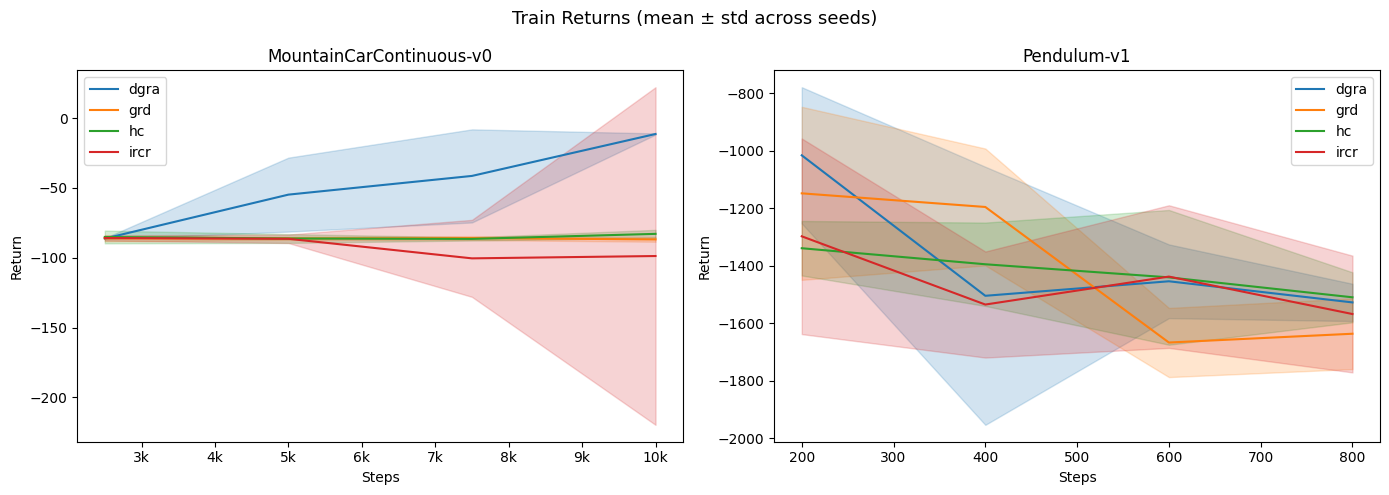

In [14]:
plot_returns(df_train_logs, "Train Returns (mean ± std across seeds)")

## Eval

In [15]:
df_eval_logs = load_logs_data(os.path.join(PATH, "eval-logs.jsonl"), specs=config_specs)

In [16]:
df_eval_logs

,episode,steps,global_steps,returns,info,env,delay,reward_model_type,update_every_n_steps,clear_buffer_on_update,...,output_dir,exp_name,run_id,eval_step_freq,n_eval_episodes,seed,agent_type,agent_kwargs,env_kwargs,algorithm
0,1,0,50,-1608.528996,"{'std_return': 129.46612296720778, 'n_eval_epi...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
1,2,0,100,-1545.669484,"{'std_return': 134.76648964905246, 'n_eval_epi...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
2,3,0,150,-1457.480861,"{'std_return': 46.924858945159684, 'n_eval_epi...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
3,4,0,200,-1573.168760,"{'std_return': 39.21066656851601, 'n_eval_epis...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
4,5,0,250,-1582.584367,"{'std_return': 54.131949264604735, 'n_eval_epi...",Pendulum-v1,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-007,1,50,5,37,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 200},hc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,16,0,8000,-0.019997,"{'std_return': 0.0012880910160300001, 'n_eval_...",MountainCarContinuous-v0,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-003,0,500,5,6,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 2500},hc
428,17,0,8500,-0.201705,"{'std_return': 0.0034041987935520004, 'n_eval_...",MountainCarContinuous-v0,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-003,0,500,5,6,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 2500},hc
429,18,0,9000,-0.096309,"{'std_return': 0.0032690991154750004, 'n_eval_...",MountainCarContinuous-v0,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-003,0,500,5,6,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 2500},hc
430,19,0,9500,-0.407613,"{'std_return': 0.00029999690527800004, 'n_eval...",MountainCarContinuous-v0,3,ircr,50,False,...,/Users/guilherme/fs/drmdp/control/drl-experime...,exp-003,0,500,5,6,hc,"{'history_hidden_size': 128, 'reg_lambda': 5.0}",{'max_episode_steps': 2500},hc


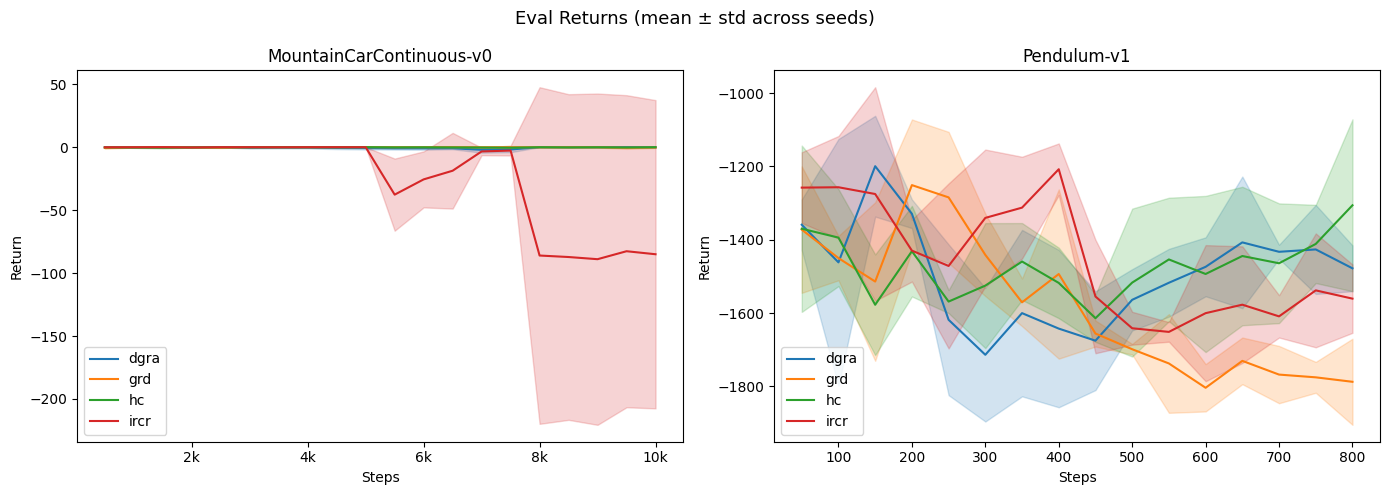

In [17]:
plot_returns(df_eval_logs, "Eval Returns (mean ± std across seeds)")